<h1 style="color: #2ecc71;">PyPI Download History Exploratory Data Analysis</h1>

This notebook analyzes PyPI package download activity to identify the most downloaded packages, their share of total downloads, and download trends over time.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns


<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Dataset Loading</h1>

This section loads the cleaned PyPI download history dataset for exploratory analysis.

In [3]:
data = r"..\data\processed\pypi_download_history_cleaned.csv"
df=pd.read_csv(data)

<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Dataset Overview</h1>

This section provides an initial inspection of the dataset structure, data types, and available download history.

In [4]:
df.head()

,package_name,date,downloads
0,beautifulsoup4,2026-04-06,9385346
1,seaborn,2026-04-06,1508171
2,jupyterlab,2026-04-06,1574802
3,black,2026-04-06,3837760
4,rich,2026-04-06,14861178


In [5]:
df.dtypes

package_name      str
date              str
downloads       int64
dtype: object

In [6]:
df["date"]=pd.to_datetime(df["date"])

<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Package Popularity Analysis</h1>

This section identifies the packages with the highest total download counts in the available download history.

In [7]:
top_n_packages=10
top_packages=df.groupby("package_name")["downloads"].sum().sort_values(ascending=False).reset_index()
top_packages.head(top_n_packages)

,package_name,downloads
0,boto3,18672705302
1,requests,9200295442
2,pydantic,6024291771
3,numpy,5904803833
4,click,5799065894
5,pytest,5322089070
6,httpx,4300030829
7,rich,3373878745
8,uvicorn,3226517582
9,litellm,2842815981


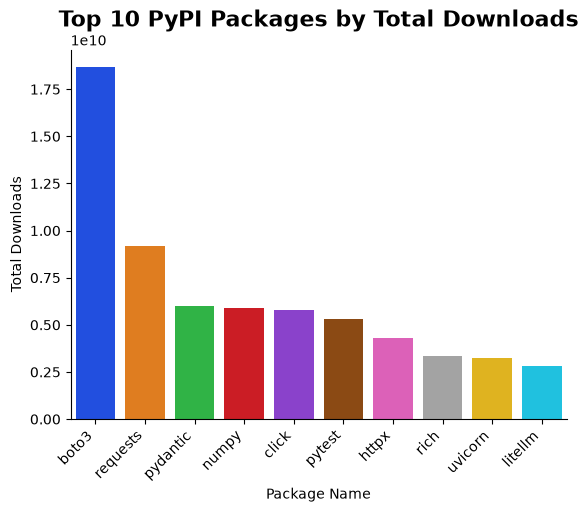

In [51]:
ax=plt.axes()
sns.barplot(
    data=top_packages.head(top_n_packages),
    x="package_name",
    y="downloads",
    hue="package_name",
    palette="bright"
)
plt.title(
    "Top 10 PyPI Packages by Total Downloads",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Package Name")
plt.ylabel("Total Downloads")
plt.xticks(rotation=45, ha="right")
ax.spines[["top","right"]].set_visible(False)
plt.show()

**What does this show?**

This chart ranks the top 10 PyPI packages based on their total downloads across the available download history.

**Key Insight:**

In [23]:
print(
    f"{top_packages.iloc[0]['package_name']} is the most downloaded package, "
    f"with {int(top_packages.iloc[0]['downloads']):,} total downloads."
)


boto3 is the most downloaded package, with 18,672,705,302 total downloads.


<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Download Share Analysis</h1>

This section compares the download share of the top packages with all remaining packages grouped together as Other.

In [9]:
donut_data=top_packages.head(10).copy()
other_downloads=top_packages.iloc[10:].sum()
donut_data.loc[len(donut_data)] = ["other", other_downloads["downloads"]]
donut_data

,package_name,downloads
0,boto3,18672705302
1,requests,9200295442
2,pydantic,6024291771
3,numpy,5904803833
4,click,5799065894
5,pytest,5322089070
6,httpx,4300030829
7,rich,3373878745
8,uvicorn,3226517582
9,litellm,2842815981


In [10]:
package_name = list(donut_data["package_name"])
colors_11 = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    "#393b79",
]
package_name

['boto3',
 'requests',
 'pydantic',
 'numpy',
 'click',
 'pytest',
 'httpx',
 'rich',
 'uvicorn',
 'litellm',
 'other']

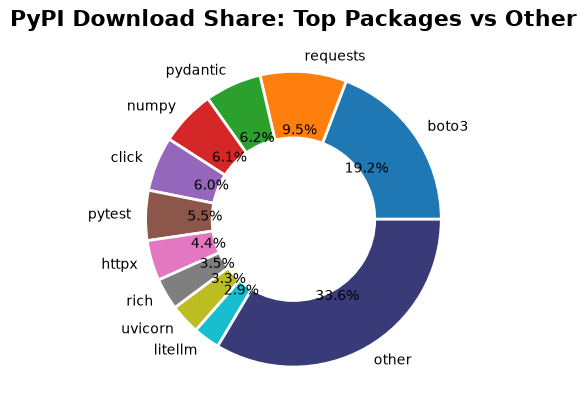

In [28]:
plt.pie(
    donut_data["downloads"],
    labels=package_name,
    autopct="%0.1f%%",
    colors=colors_11,
    wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize":10}
)
plt.title(
    "PyPI Download Share: Top Packages vs Other",
    fontsize=16,
    fontweight="bold",
)

plt.show()

**What does this show?**

This donut chart shows how total downloads are distributed among the top 10 packages, while all remaining packages are grouped into the Other segment.

**Key Insight:**

In [29]:
top_package_share = (
    donut_data.iloc[0]["downloads"] / donut_data["downloads"].sum()
) * 100

print(
    f"{donut_data.iloc[0]['package_name']} accounts for approximately "
    f"{top_package_share:.1f}% of the downloads represented in this chart."
)


boto3 accounts for approximately 19.2% of the downloads represented in this chart.


<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Top Package Download Trends</h1>

This section tracks the monthly download activity of the five most downloaded packages to compare how their popularity changes over time.

In [31]:
df["months"]=df["date"].dt.month_name()


In [13]:
top_n=5
top_packages_list = list(top_packages["package_name"].values)[:top_n]
top_packages_list

['boto3', 'requests', 'pydantic', 'numpy', 'click']

In [30]:
top_downloads_over_time=df[df["package_name"].isin(top_packages_list)].groupby(["months","package_name"])['downloads'].sum().reset_index()


In [33]:
month_order = ["April", "May", "June", "July", "August", "September", "October"]
top_downloads_over_time["months"] = pd.Categorical(
    top_downloads_over_time["months"], categories=month_order, ordered=True
)
top_downloads_over_time = top_downloads_over_time.sort_values("months")
pivot_df = top_downloads_over_time.pivot(
    index="months", columns="package_name", values="downloads"
)
pivot_df


package_name,boto3,click,numpy,pydantic,requests
months,,,,,
April,2337992152,790518057,768247380,815433437,1258210282
May,3281155850,987526917,977059915,1058574318,1600926553
June,3573594234,997359025,1084121364,1057038017,1647111902
July,3715255664,1088503918,1137711486,1102195212,1750883315
August,3221807176,1090305356,1111695120,1117953484,1694439177
September,2455447260,810070226,793258595,838410099,1199537437
October,87452966,34782395,32709973,34687204,49186776


In [40]:
fig = px.line(
    top_downloads_over_time,
    x="months",
    y="downloads",
    color="package_name",
    markers=True,
    title="Monthly Download Trends of Top 5 Packages"
)
fig.update_layout(
    xaxis_title="Months",
    yaxis_title="Downloads",
    template="plotly_white",
    title={
        "x": 0.5,
        "font": {"size": 20, "color": "#111827", "style": "italic", "weight": "bold"},
    },
    xaxis={
        "showgrid": True,
        "gridcolor": "#c3c8d2",
    },
    yaxis={
        "showgrid": True,
        "gridcolor": "#c3c8d2",
    },
)

fig.show()

**What does this show?**

This chart compares monthly download trends for the five most downloaded packages and highlights changes in their download activity over time.

**Key Insight:**

In [41]:
peak_row = top_downloads_over_time.loc[top_downloads_over_time["downloads"].idxmax()]

print(
    f"{peak_row['package_name']} recorded the highest monthly download count "
    f"in {peak_row['months']} with {int(peak_row['downloads']):,} downloads."
)


boto3 recorded the highest monthly download count in July with 3,715,255,664 downloads.


<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Overall Download Activity</h1>

This section examines the total number of PyPI downloads recorded across all packages for each month.

In [17]:
downloads_over_months=df.groupby("months")["downloads"].sum().sort_values(ascending=False).reset_index()
month_order = ["April", "May", "June", "July", "August", "September", "October"]
downloads_over_months["months"] = pd.Categorical(
    downloads_over_months["months"], categories=month_order, ordered=True
)
downloads_over_months = downloads_over_months.sort_values("months")
downloads_over_months

,months,downloads
5,April,12593112268
3,May,16482629803
2,June,17840080948
0,July,18849372483
1,August,18161714775
4,September,12873479546
6,October,519696569


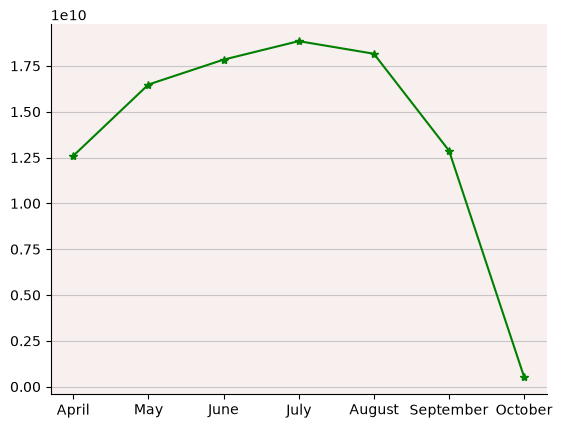

In [64]:
ax=plt.axes()
ax.set_facecolor("#F8EFEF")
plt.plot(downloads_over_months["months"],downloads_over_months["downloads"],marker="*",linewidth=1.5,color="green")
plt.grid(axis="y", color="#5d636e",alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.show()

**What does this show?**

This chart shows the overall download volume across all packages for each month in the dataset.

**Key Insight:**

In [65]:
peak_month = downloads_over_months.loc[downloads_over_months["downloads"].idxmax()]

print(
    f"{peak_month['months']} recorded the highest overall download activity, "
    f"with {int(peak_month['downloads']):,} downloads."
)


July recorded the highest overall download activity, with 18,849,372,483 downloads.


<h1 style="color: #2ecc71;">Final Key Findings</h1>

The analysis summarizes package popularity, download concentration, and overall download activity across the available PyPI download history.

In [66]:
print("\n" + "=" * 65)
print("FINAL KEY FINDINGS")
print("=" * 65)

print(
    f"\n1. Most Downloaded Package: {top_packages.iloc[0]['package_name']} "
    f"recorded {int(top_packages.iloc[0]['downloads']):,} total downloads."
)

print(
    f"\n2. Download Concentration: {donut_data.iloc[0]['package_name']} "
    f"accounts for approximately {top_package_share:.1f}% of the "
    f"downloads represented in the top-package distribution."
)

print(
    f"\n3. Top Package Trend: {peak_row['package_name']} recorded the "
    f"highest monthly download count in {peak_row['months']}."
)

print(
    f"\n4. Overall Activity: {peak_month['months']} had the highest "
    f"overall download activity with {int(peak_month['downloads']):,} downloads."
)



FINAL KEY FINDINGS

1. Most Downloaded Package: boto3 recorded 18,672,705,302 total downloads.

2. Download Concentration: boto3 accounts for approximately 19.2% of the downloads represented in the top-package distribution.

3. Top Package Trend: boto3 recorded the highest monthly download count in July.

4. Overall Activity: July had the highest overall download activity with 18,849,372,483 downloads.
